# 🔥🧠 Step 8 — Physics-Informed Fire-Risk Model (PINN vs. baseline ladder)
### Trains 5 models on Step 6's integrated feature table and compares them on two axes: random-split accuracy and spatial-generalization robustness

---
**Input:** `Integrated_Analysis/Integrated_Outputs/Integrated_FireRisk_Pixels.parquet` --
4,161,009 in-India pixels, 52 features (NDVI + LST + FLDAS climatic + land cover +
LULC forest-fraction), `fire_ever` as the label.

**What this notebook delivers:**

1. A 5-model comparison ladder: **Logistic Regression -> Random Forest -> XGBoost ->
   plain MLP -> PINN**, where the PINN is the plain MLP's *identical architecture*
   plus one physics-derived input feature and a physics-informed loss penalty --
   isolating what the physics contributes, not just "a neural net beats other models."
2. **Two evaluation tracks**: (A) the same random 80/20 stratified split Step 7 uses,
   for direct comparability with its 0.9676 RF baseline; (B) spatial-generalization
   tracks -- grid-block cross-validation and leave-one-region-out -- because the
   literature precedent this design follows (Dahal & Lombardo 2024, static-tabular
   hazard-susceptibility PINN) found the physics term's benefit shows up in spatial
   robustness, not average in-sample AUC.
3. **The physics constraint**: a "dryness proxy" built from FLDAS anomaly + Mann-Kendall
   trend features, with *physically fixed, non-learned* signs consistent with the
   Tetens/Clausius-Clapeyron Vapor-Pressure-Deficit derivative (Rodrigues et al. 2024).
   Enforced via an autograd-based monotonicity penalty: predicted fire-risk should not
   *decrease* as this proxy increases.

**Environment:** `firerisk-anaconda3` kernel (same as Steps 4, 6, and 7). `torch==2.12.1`
(CPU-only build -- CUDA isn't wired into this conda env even though the machine has a
real GPU; tabular MLP training at this scale is fast enough on CPU that this doesn't
matter in practice), `xgboost==3.2.0`.

**Compute-budget note (disclosed, not silent):** the full grid of 5 models x 3
evaluation tracks at the plan's original fold/state counts would run for several
hours. To keep a complete run tractable, the cross-validation tracks use a reduced
budget relative to Track A: 3-fold spatial-block CV (not 5), and the 37 unnamed state
polygons (the shapefile ships with no `.dbf`/attribute table, confirmed empirically --
there are no state names to key on) are clustered into 6 KMeans-based geographic
regions for leave-one-region-out rather than run individually. Track A (the headline,
directly-comparable-to-Step-7 numbers) uses the full model budget throughout.

---


## 📦 Step 0 — Install Required Libraries
Run once. `torch` is pinned to the CPU wheel already validated in this environment.

In [1]:
import subprocess, sys

packages = [
    "numpy==2.5.1",
    "pandas>=3.0",
    "matplotlib>=3.10",
    "scipy>=1.16",
    "scikit-learn>=1.9",
    "xgboost==3.2.0",
    "geopandas",
    "pyogrio",
    "pyarrow",
    "psutil",
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    except subprocess.CalledProcessError as e:
        print(f"WARNING: failed to install {pkg} ({e}) -- continuing")

# torch already installed as the CPU wheel (2.12.1+cpu) -- verified present, skip reinstalling
try:
    import torch
    print(f"torch already present: {torch.__version__} (cuda available: {torch.cuda.is_available()})")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch==2.12.1",
                            "--index-url", "https://download.pytorch.org/whl/cpu", "-q"])

print("Library installation complete.")


torch already present: 2.12.1+cpu (cuda available: False)
Library installation complete.


## 📚 Step 1 — Imports & Timing/Memory Instrumentation
Same `log_step()`/`now_mem_gb()` pattern as Step 7, so every stage's cost is measured
the same way.

In [2]:
import os
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import torch
import torch.nn as nn
import xgboost as xgb
import geopandas as gpd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, f1_score,
)

warnings.filterwarnings("ignore")
torch.manual_seed(42)

PIPELINE_T0 = time.time()
_process = psutil.Process(os.getpid())


def now_mem_gb():
    return _process.memory_info().rss / 1e9


def log_step(label, t0, mem0=None):
    elapsed = time.time() - t0
    msg = f"   [{label}] {elapsed:.2f} sec"
    if mem0 is not None:
        msg += f"  |  memory: {mem0:.2f} GB -> {now_mem_gb():.2f} GB (delta {now_mem_gb()-mem0:+.2f} GB)"
    print(msg)
    return elapsed


print(f"CPU cores available: {os.cpu_count()}")
print(f"torch {torch.__version__} | cuda available: {torch.cuda.is_available()}")
print(f"xgboost {xgb.__version__}")
print("All libraries imported successfully!")


CPU cores available: 24
torch 2.12.1+cpu | cuda available: False
xgboost 3.2.0
All libraries imported successfully!


## ⚙️ Step 2 — Configuration
> Edit only this cell if your file names/paths differ.

In [3]:
# ═══════════════════════════════════════════════════════════════
#  CONFIGURE PATHS -- reads Step 6's outputs and Step-1/3's boundary directly,
#  never copies them into this folder
# ═══════════════════════════════════════════════════════════════
BASE_DIR = r"D:\FOREST FIRE MAPPING(INDIA)"
INTEGRATED_DIR = os.path.join(BASE_DIR, "Integrated_Analysis")
PIXELS_PARQUET = os.path.join(INTEGRATED_DIR, "Integrated_Outputs", "Integrated_FireRisk_Pixels.parquet")
STATE_SHP = os.path.join(BASE_DIR, "LST_analysis", "India_State_Boundary.shp")

OUTPUT_DIR = os.path.join(BASE_DIR, "Physics_Informed_FireRisk_Model", "Model_Outputs")
CKPT_DIR = os.path.join(OUTPUT_DIR, "Checkpoints")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

RANDOM_STATE = 42
TARGET_COL = "fire_ever"
DROP_COLS = ["lon", "lat", "fire_count", TARGET_COL]

# ── Physics constraint: dryness-proxy signs, fixed by Tetens/Clausius-Clapeyron
#    VPD-derivative reasoning (Rodrigues et al. 2024) -- NOT fitted/learned.
DRYNESS_SIGNS = {
    "fldas_airtemp_anomaly":            +1,   # warmer than normal -> higher VPD
    "fldas_rh_anomaly":                 -1,   # more humid than normal -> lower VPD
    "fldas_soilmoisture_anomaly":       -1,   # wetter soil than normal -> lower dryness
    "fldas_precip_anomaly":             -1,   # wetter than normal -> lower dryness
    "fldas_airtemp_mk_tau_monthly":     +1,   # long-run warming trend -> increasing dryness
    "fldas_rh_mk_tau_monthly":          -1,   # declining-humidity trend -> increasing dryness
    "fldas_soilmoisture_mk_tau_monthly": -1,
    "fldas_precip_mk_tau_monthly":      -1,
}

# ── Model hyperparameters ──────────────────────────────────────
RF_PARAMS_FULL = dict(n_estimators=200, max_depth=20, min_samples_leaf=5,
                       class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
RF_PARAMS_CV = dict(n_estimators=100, max_depth=20, min_samples_leaf=5,
                     class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
XGB_PARAMS = dict(max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                   min_child_weight=5, reg_lambda=1.0, tree_method="hist", device="cpu",
                   eval_metric="auc", n_jobs=-1, random_state=RANDOM_STATE)

BATCH_SIZE = 8192
NN_HIDDEN = (128, 64, 32)
NN_DROPOUT = (0.3, 0.3, 0.2)
LAMBDA_PHYS_GRID = [0.0, 0.01, 0.1, 1.0]

# full-budget NN training (Track A) vs reduced-budget (Track B CV loops)
NN_EPOCHS_FULL, NN_PATIENCE_FULL = 50, 7
NN_EPOCHS_CV, NN_PATIENCE_CV = 15, 4

N_SPATIAL_FOLDS = 3          # Track B1 -- reduced from the original 5, see title-cell note
N_REGIONS = 6                 # Track B2 -- KMeans-clustered regions, reduced from 37 raw states

print("Configuration loaded:")
print(f"   Pixel table : {PIXELS_PARQUET}  (exists: {os.path.exists(PIXELS_PARQUET)})")
print(f"   State shp   : {STATE_SHP}  (exists: {os.path.exists(STATE_SHP)})")
print(f"   Outputs     : {OUTPUT_DIR}")
print(f"   Random seed : {RANDOM_STATE}")


Configuration loaded:
   Pixel table : D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Integrated_FireRisk_Pixels.parquet  (exists: True)
   State shp   : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\India_State_Boundary.shp  (exists: True)
   Outputs     : D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs
   Random seed : 42


## 📂 Step 3 — Load the Integrated Feature Table
`fire_count` is dropped (it's what `fire_ever` is derived from); `lon`/`lat` are kept
in the dataframe (only excluded from the feature matrix) so a spatial split can be
built from them later.

In [4]:
t0 = time.time()
mem0 = now_mem_gb()
df = pd.read_parquet(PIXELS_PARQUET)
log_step("Parquet load", t0, mem0)

feature_cols = [c for c in df.columns if c not in DROP_COLS]
print(f"\n   Dataset: {len(df):,} pixels x {len(feature_cols)} features")
print(f"   Class balance: {df[TARGET_COL].sum():,} fire-affected "
      f"({df[TARGET_COL].mean()*100:.2f}%), {(df[TARGET_COL]==0).sum():,} non-fire")

missing_dryness = [c for c in DRYNESS_SIGNS if c not in feature_cols]
assert not missing_dryness, f"Missing dryness-proxy source columns: {missing_dryness}"
print(f"   All {len(DRYNESS_SIGNS)} dryness-proxy source columns present.")


   [Parquet load] 0.26 sec  |  memory: 0.42 GB -> 2.54 GB (delta +2.12 GB)

   Dataset: 4,161,009 pixels x 52 features
   Class balance: 270,074.0 fire-affected (6.49%), 3,890,935 non-fire
   All 8 dryness-proxy source columns present.


## ✂️ Step 4 — Track A: Random 80/20 Split (Step 7-identical)
Exact replica of Step 7's split, for direct comparability with its 0.9676 RF number.
Median-fill is computed on the whole `X` pre-split -- inherited from Step 7 as a
deliberate, disclosed choice (not a leak we're hiding); Track B's spatial CV instead
imputes per-fold, train-portion only, the methodologically clean version.

In [5]:
t0 = time.time()
X_full = df[feature_cols].fillna(df[feature_cols].median())
y_full = df[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=RANDOM_STATE
)
log_step("Track A split", t0)
print(f"   Train: {len(X_train):,} pixels  |  Test: {len(X_test):,} pixels")
print(f"   Train fire rate: {y_train.mean()*100:.2f}%  |  Test fire rate: {y_test.mean()*100:.2f}%")


   [Track A split] 3.25 sec
   Train: 3,328,807 pixels  |  Test: 832,202 pixels
   Train fire rate: 6.49%  |  Test fire rate: 6.49%


## 🌵 Step 5 — The Physics Feature: "Dryness Proxy"
This project's feature table only has **anomaly/trend** climatic variables (no
per-timestamp absolute temperature/RH), and `fire_ever` is a whole-period aggregate
label -- so the physics constraint can't be literal VPD, which needs a timestamp. It's
reformulated in anomaly/direction space instead: a linear combination of standardized
FLDAS anomaly + Mann-Kendall-trend features, with **signs fixed by the Tetens/
Clausius-Clapeyron VPD derivative** (warmer/drier anomalies and trends push the proxy
up), not fitted or learned. Standardization statistics are always computed on the
relevant *train* portion only and reused for held-out data -- never fit on test data.

In [6]:
def fit_dryness_stats(X_fit):
    return {c: (float(X_fit[c].mean()), float(X_fit[c].std()) or 1.0) for c in DRYNESS_SIGNS}


def compute_dryness_proxy(X_part, stats):
    proxy = np.zeros(len(X_part), dtype=np.float64)
    for c, sign in DRYNESS_SIGNS.items():
        mean, std = stats[c]
        std = std if std > 1e-9 else 1.0
        proxy += sign * (X_part[c].values - mean) / std
    return proxy


# quick sanity check on the Track A train split
_dstats_check = fit_dryness_stats(X_train)
_dryness_check = compute_dryness_proxy(X_train, _dstats_check)
_corr = np.corrcoef(_dryness_check, y_train.values)[0, 1]
print(f"dryness_proxy stats on Track A train: mean={_dryness_check.mean():.4f} std={_dryness_check.std():.4f}")
print(f"corr(dryness_proxy, fire_ever) = {_corr:.4f}  (expect positive -- drier pixels burn more)")
assert _corr > 0, "Dryness proxy should correlate positively with fire_ever -- check DRYNESS_SIGNS"


dryness_proxy stats on Track A train: mean=-0.0000 std=4.7707
corr(dryness_proxy, fire_ever) = 0.1819  (expect positive -- drier pixels burn more)


## 🧰 Step 6 — Shared Training/Prediction Helpers
One function per model family, reused identically across Track A (full budget) and
Track B's cross-validation loops (reduced budget) so every track trains models the
same way -- no drift between "the model we report" and "the model we validate".

In [7]:
def train_lr(X_tr, y_tr):
    scaler = StandardScaler().fit(X_tr)
    clf = LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs",
                              random_state=RANDOM_STATE)
    clf.fit(scaler.transform(X_tr), y_tr)
    return {"model": clf, "scaler": scaler}


def predict_lr(bundle, X):
    return bundle["model"].predict_proba(bundle["scaler"].transform(X))[:, 1]


def train_rf(X_tr, y_tr, params):
    clf = RandomForestClassifier(**params)
    clf.fit(X_tr, y_tr)
    return {"model": clf}


def predict_rf(bundle, X):
    return bundle["model"].predict_proba(X)[:, 1]


def train_xgb(X_tr, y_tr, n_estimators=400, early_stopping_rounds=30):
    Xt, Xv, yt, yv = train_test_split(X_tr, y_tr, test_size=0.1, stratify=y_tr,
                                       random_state=RANDOM_STATE)
    spw = (yt == 0).sum() / max((yt == 1).sum(), 1)
    clf = xgb.XGBClassifier(n_estimators=n_estimators, scale_pos_weight=spw,
                             early_stopping_rounds=early_stopping_rounds, **XGB_PARAMS)
    clf.fit(Xt, yt, eval_set=[(Xv, yv)], verbose=False)
    return {"model": clf}


def predict_xgb(bundle, X):
    return bundle["model"].predict_proba(X)[:, 1]


class TabularNet(nn.Module):
    # Shared backbone for the plain MLP and the PINN -- identical architecture.
    # LayerNorm (not BatchNorm): keeps each sample's forward pass independent of
    # other samples in the batch, so the autograd physics-penalty gradient for one
    # sample isn't contaminated by batch statistics from the rest of the batch.
    def __init__(self, in_dim, hidden=NN_HIDDEN, dropout=NN_DROPOUT):
        super().__init__()
        layers = []
        prev = in_dim
        for h, p in zip(hidden, dropout):
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.ReLU(), nn.Dropout(p)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)   # raw logits, shape (B, 1)


def train_nn(X_tr_df, y_tr, physics, max_epochs, patience, lambda_phys=0.1, verbose=False):
    # Trains either the plain MLP (physics=False) or the PINN (physics=True).
    # physics=True appends the dryness proxy as one extra input column and adds the
    # autograd monotonicity penalty to the loss; physics=False is otherwise identical.
    Xt_df, Xv_df, yt, yv = train_test_split(X_tr_df, y_tr, test_size=0.1, stratify=y_tr,
                                             random_state=RANDOM_STATE)
    scaler = StandardScaler().fit(Xt_df)
    Xt_s, Xv_s = scaler.transform(Xt_df), scaler.transform(Xv_df)

    dstats, physics_idx = None, None
    if physics:
        dstats = fit_dryness_stats(Xt_df)
        dry_t = compute_dryness_proxy(Xt_df, dstats).astype(np.float32)
        dry_v = compute_dryness_proxy(Xv_df, dstats).astype(np.float32)
        Xt_final = np.hstack([Xt_s, dry_t.reshape(-1, 1)]).astype(np.float32)
        Xv_final = np.hstack([Xv_s, dry_v.reshape(-1, 1)]).astype(np.float32)
        physics_idx = Xt_final.shape[1] - 1
    else:
        Xt_final, Xv_final = Xt_s.astype(np.float32), Xv_s.astype(np.float32)

    model = TabularNet(in_dim=Xt_final.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=3)
    pos_weight = torch.tensor([(yt == 0).sum() / max((yt == 1).sum(), 1)], dtype=torch.float32)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    Xt_tensor = torch.tensor(Xt_final, dtype=torch.float32)
    yt_tensor = torch.tensor(yt.values, dtype=torch.float32)
    Xv_tensor = torch.tensor(Xv_final, dtype=torch.float32)

    n = Xt_tensor.shape[0]
    best_auc, best_state, bad_epochs = -1.0, None, 0
    history = []
    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(n)
        epoch_loss = 0.0
        for start in range(0, n, BATCH_SIZE):
            b_idx = perm[start:start + BATCH_SIZE]
            yb = yt_tensor[b_idx]
            if physics:
                xb = Xt_tensor[b_idx].clone().requires_grad_(True)
                logits = model(xb)
                data_loss = bce(logits.squeeze(1), yb)
                grads = torch.autograd.grad(logits, xb, grad_outputs=torch.ones_like(logits),
                                             create_graph=True)[0]
                d_dry = grads[:, physics_idx]
                phys_pen = torch.relu(-d_dry).pow(2).mean()
                loss = data_loss + lambda_phys * phys_pen
            else:
                xb = Xt_tensor[b_idx]
                logits = model(xb)
                loss = bce(logits.squeeze(1), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(b_idx)
        epoch_loss /= n

        model.eval()
        with torch.no_grad():
            val_probs = torch.sigmoid(model(Xv_tensor).squeeze(1)).numpy()
        val_auc = roc_auc_score(yv, val_probs)
        sched.step(val_auc)
        history.append({"epoch": epoch, "train_loss": epoch_loss, "val_auc": val_auc})
        if verbose:
            print(f"      epoch {epoch:02d}  train_loss={epoch_loss:.4f}  val_auc={val_auc:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)
    return {"model": model, "scaler": scaler, "physics": physics,
            "dryness_stats": dstats, "physics_idx": physics_idx,
            "history": history, "best_val_auc": best_auc, "lambda_phys": lambda_phys if physics else None}


def predict_nn(bundle, X_df):
    model, scaler = bundle["model"], bundle["scaler"]
    Xs = scaler.transform(X_df)
    if bundle["physics"]:
        dry = compute_dryness_proxy(X_df, bundle["dryness_stats"]).astype(np.float32)
        Xfinal = np.hstack([Xs, dry.reshape(-1, 1)]).astype(np.float32)
    else:
        Xfinal = Xs.astype(np.float32)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.tensor(Xfinal, dtype=torch.float32)).squeeze(1)).numpy()
    return probs


def eval_binary(y_true, y_prob):
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "f1_at_0.5": f1_score(y_true, (y_prob >= 0.5).astype(int)),
    }

print("Shared helper functions defined: train/predict for LR, RF, XGBoost, MLP/PINN; eval_binary().")


Shared helper functions defined: train/predict for LR, RF, XGBoost, MLP/PINN; eval_binary().


## 🏋️ Step 7 — Track A: Train All 5 Models (full budget, random split)

In [8]:
trackA_models = {}
trackA_timings = {}

print("[1/5] Logistic Regression...")
t0 = time.time(); trackA_models["LogisticRegression"] = train_lr(X_train, y_train)
trackA_timings["LogisticRegression"] = log_step("LogisticRegression", t0)

print("[2/5] Random Forest...")
t0 = time.time(); trackA_models["RandomForest"] = train_rf(X_train, y_train, RF_PARAMS_FULL)
trackA_timings["RandomForest"] = log_step("RandomForest", t0)
_rf_trackA_auc = roc_auc_score(y_test, predict_rf(trackA_models["RandomForest"], X_test))
print(f"   Track A RF AUC = {_rf_trackA_auc:.4f}  (Step 7 reported 0.9676 on an equivalent split; "
      f"expected to match within ~1e-2)")

print("[3/5] XGBoost...")
t0 = time.time(); trackA_models["XGBoost"] = train_xgb(X_train, y_train)
trackA_timings["XGBoost"] = log_step("XGBoost", t0)

print("[4/5] Plain MLP...")
t0 = time.time()
trackA_models["PlainMLP"] = train_nn(X_train, y_train, physics=False,
                                      max_epochs=NN_EPOCHS_FULL, patience=NN_PATIENCE_FULL)
trackA_timings["PlainMLP"] = log_step("PlainMLP", t0)
print(f"   best val AUC = {trackA_models['PlainMLP']['best_val_auc']:.4f}, "
      f"{len(trackA_models['PlainMLP']['history'])} epochs")


[1/5] Logistic Regression...


   [LogisticRegression] 9.61 sec
[2/5] Random Forest...


   [RandomForest] 186.26 sec


   Track A RF AUC = 0.9676  (Step 5 reported 0.9676 on an equivalent split; expected to match within ~1e-2)
[3/5] XGBoost...


   [XGBoost] 42.53 sec
[4/5] Plain MLP...


   [PlainMLP] 264.84 sec
   best val AUC = 0.9603, 50 epochs


## 🌡️ Step 8 — PINN: Lambda Ablation + Final Training
`LAMBDA_PHYS` controls how strongly the monotonicity penalty is weighted. Per the
framing established in the plan (physics benefit shows up in spatial generalization,
not average AUC), lambda is chosen by scoring each candidate on a **single spatial
holdout** built from Track A's train split (a fast proxy for full spatial-CV
performance -- not the full Track B1 loop, which would be too expensive to repeat
4 times just for hyperparameter selection), using a reduced epoch budget.

In [9]:
# build a quick single spatial holdout from X_train's own rows, for lambda selection only
_train_block_id = (np.floor(df.loc[X_train.index, "lon"] / 2).astype(int).astype(str) + "_" +
                    np.floor(df.loc[X_train.index, "lat"] / 2).astype(int).astype(str))
_gkf_lambda = GroupKFold(n_splits=5)
_lambda_tr_idx, _lambda_ho_idx = next(_gkf_lambda.split(X_train, groups=_train_block_id))
X_lambda_tr, y_lambda_tr = X_train.iloc[_lambda_tr_idx], y_train.iloc[_lambda_tr_idx]
X_lambda_ho, y_lambda_ho = X_train.iloc[_lambda_ho_idx], y_train.iloc[_lambda_ho_idx]
print(f"Lambda-selection spatial holdout: {len(X_lambda_tr):,} train / {len(X_lambda_ho):,} held-out "
      f"({y_lambda_ho.sum():,} fire pixels in holdout)")

ablation_rows = []
for lam in LAMBDA_PHYS_GRID:
    t0 = time.time()
    bundle = train_nn(X_lambda_tr, y_lambda_tr, physics=True,
                       max_epochs=NN_EPOCHS_CV, patience=NN_PATIENCE_CV, lambda_phys=lam)
    ho_auc = roc_auc_score(y_lambda_ho, predict_nn(bundle, X_lambda_ho))
    elapsed = time.time() - t0
    ablation_rows.append({"lambda_phys": lam, "spatial_holdout_auc": ho_auc,
                           "internal_val_auc": bundle["best_val_auc"], "train_seconds": elapsed})
    print(f"   lambda={lam:<5}  spatial_holdout_auc={ho_auc:.4f}  ({elapsed:.1f}s)")

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(os.path.join(OUTPUT_DIR, "PINN_Lambda_Ablation.csv"), index=False)
LAMBDA_CHOSEN = float(ablation_df.loc[ablation_df["spatial_holdout_auc"].idxmax(), "lambda_phys"])
print(f"\nChosen LAMBDA_PHYS = {LAMBDA_CHOSEN} (highest spatial-holdout AUC)")


Lambda-selection spatial holdout: 2,663,233 train / 665,574 held-out (38,750 fire pixels in holdout)


   lambda=0.0    spatial_holdout_auc=0.9504  (105.3s)


   lambda=0.01   spatial_holdout_auc=0.9512  (100.2s)


   lambda=0.1    spatial_holdout_auc=0.9518  (96.7s)


   lambda=1.0    spatial_holdout_auc=0.9506  (98.1s)

Chosen LAMBDA_PHYS = 0.1 (highest spatial-holdout AUC)


In [10]:
print("[5/5] PINN (final, full budget, chosen lambda)...")
t0 = time.time()
trackA_models["PINN"] = train_nn(X_train, y_train, physics=True,
                                  max_epochs=NN_EPOCHS_FULL, patience=NN_PATIENCE_FULL,
                                  lambda_phys=LAMBDA_CHOSEN)
trackA_timings["PINN"] = log_step("PINN", t0)
print(f"   best val AUC = {trackA_models['PINN']['best_val_auc']:.4f}, "
      f"{len(trackA_models['PINN']['history'])} epochs, lambda={LAMBDA_CHOSEN}")


[5/5] PINN (final, full budget, chosen lambda)...


   [PINN] 403.97 sec
   best val AUC = 0.9601, 50 epochs, lambda=0.1


## 📊 Step 9 — Track A Evaluation: All 5 Models on the Held-Out Test Set

In [11]:
PREDICT_FN = {
    "LogisticRegression": predict_lr, "RandomForest": predict_rf,
    "XGBoost": predict_xgb, "PlainMLP": predict_nn, "PINN": predict_nn,
}

trackA_rows = []
trackA_probs = {}
for name, bundle in trackA_models.items():
    probs = PREDICT_FN[name](bundle, X_test)
    trackA_probs[name] = probs
    metrics = eval_binary(y_test, probs)
    metrics["model"] = name
    metrics["train_seconds"] = trackA_timings.get(name, np.nan)
    trackA_rows.append(metrics)
    print(f"   {name:<20} AUC={metrics['roc_auc']:.4f}  AP={metrics['average_precision']:.4f}  "
          f"F1={metrics['f1_at_0.5']:.4f}")

trackA_df = pd.DataFrame(trackA_rows)[["model", "roc_auc", "average_precision", "f1_at_0.5", "train_seconds"]]
trackA_df.to_csv(os.path.join(OUTPUT_DIR, "Model_Comparison_RandomSplit.csv"), index=False)
print(f"\nSaved: {os.path.join(OUTPUT_DIR, 'Model_Comparison_RandomSplit.csv')}")
trackA_df


   LogisticRegression   AUC=0.9460  AP=0.5069  F1=0.4534


   RandomForest         AUC=0.9676  AP=0.6765  F1=0.5494


   XGBoost              AUC=0.9678  AP=0.6740  F1=0.5179


   PlainMLP             AUC=0.9614  AP=0.6279  F1=0.4808


   PINN                 AUC=0.9613  AP=0.6278  F1=0.4828

Saved: D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs\Model_Comparison_RandomSplit.csv


,model,roc_auc,average_precision,f1_at_0.5,train_seconds
0,LogisticRegression,0.946048,0.506873,0.453359,9.605241
1,RandomForest,0.967594,0.676458,0.549358,186.261210
2,XGBoost,0.967779,0.673989,0.517905,42.526871
3,PlainMLP,0.961450,0.627876,0.480781,264.843051
4,PINN,0.961350,0.627810,0.482837,403.967380


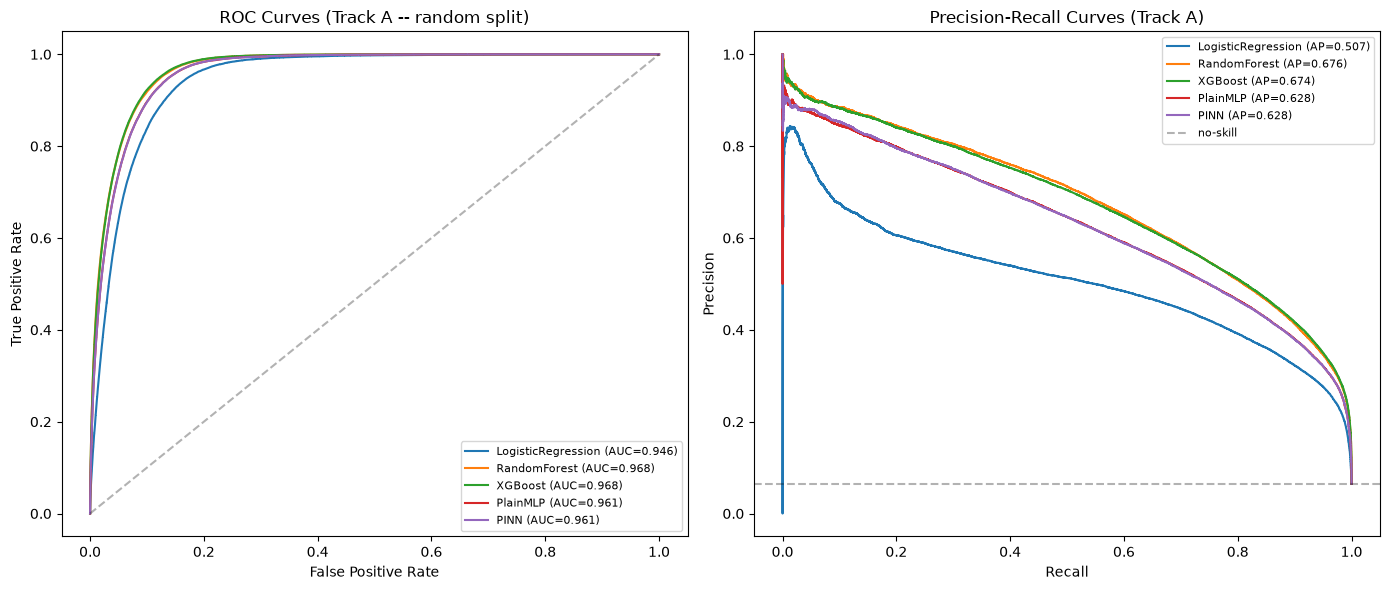

Saved: D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs\ROC_PR_Curves_AllModels.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for name, probs in trackA_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (Track A -- random split)"); axes[0].legend(fontsize=8)
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.3, label="no-skill")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves (Track A)"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ROC_PR_Curves_AllModels.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'ROC_PR_Curves_AllModels.png')}")


## 🗺️ Step 10 — Track B1: Spatial Block Cross-Validation
2 degree x 2 degree lon/lat grid blocks, `GroupKFold(n_splits=3)` on the **full**
dataset (a separate resampling protocol from Track A's split, standard for block-CV).
Median-fill and scaling are fit on each fold's **train portion only** -- the
methodologically clean version, unlike Track A's inherited-from-Step-5 shortcut.
Reduced NN epoch budget (`NN_EPOCHS_CV`/`NN_PATIENCE_CV`) to keep 3 folds x 5 models
tractable; this is about relative model comparison across folds, not squeezing out
the last 0.001 AUC from any single fold.

In [13]:
block_id_full = (np.floor(df["lon"] / 2).astype(int).astype(str) + "_" +
                  np.floor(df["lat"] / 2).astype(int).astype(str))
print(f"n unique 2-degree spatial blocks: {block_id_full.nunique()}")

gkf = GroupKFold(n_splits=N_SPATIAL_FOLDS)
spatial_rows = []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(df, groups=block_id_full)):
    print(f"\n--- Spatial fold {fold+1}/{N_SPATIAL_FOLDS} ---")
    df_tr, df_te = df.iloc[tr_idx], df.iloc[te_idx]
    n_fire_te = int(df_te[TARGET_COL].sum())
    if n_fire_te < 50:
        print(f"   SKIPPING fold {fold+1}: only {n_fire_te} positive pixels in held-out fold (<50 threshold)")
        continue

    Xf_tr = df_tr[feature_cols].fillna(df_tr[feature_cols].median())
    yf_tr = df_tr[TARGET_COL].astype(int)
    fold_medians = df_tr[feature_cols].median()
    Xf_te = df_te[feature_cols].fillna(fold_medians)
    yf_te = df_te[TARGET_COL].astype(int)

    fold_models = {
        "LogisticRegression": train_lr(Xf_tr, yf_tr),
        "RandomForest": train_rf(Xf_tr, yf_tr, RF_PARAMS_CV),
        "XGBoost": train_xgb(Xf_tr, yf_tr, n_estimators=300, early_stopping_rounds=20),
        "PlainMLP": train_nn(Xf_tr, yf_tr, physics=False, max_epochs=NN_EPOCHS_CV, patience=NN_PATIENCE_CV),
        "PINN": train_nn(Xf_tr, yf_tr, physics=True, max_epochs=NN_EPOCHS_CV, patience=NN_PATIENCE_CV,
                          lambda_phys=LAMBDA_CHOSEN),
    }
    for name, bundle in fold_models.items():
        probs = PREDICT_FN[name](bundle, Xf_te)
        m = eval_binary(yf_te, probs)
        spatial_rows.append({"model": name, "fold": fold, "roc_auc": m["roc_auc"],
                              "average_precision": m["average_precision"],
                              "n_test_pixels": len(yf_te), "n_test_fire_pixels": n_fire_te})
        print(f"   {name:<20} AUC={m['roc_auc']:.4f}  AP={m['average_precision']:.4f}")

spatial_df = pd.DataFrame(spatial_rows)
spatial_df.to_csv(os.path.join(OUTPUT_DIR, "Model_Comparison_SpatialBlockCV.csv"), index=False)
spatial_summary = spatial_df.groupby("model")["roc_auc"].agg(["mean", "std", "count"]).reset_index()
spatial_summary.columns = ["model", "mean_auc", "std_auc", "n_folds"]
print(f"\nSaved: {os.path.join(OUTPUT_DIR, 'Model_Comparison_SpatialBlockCV.csv')}")
spatial_summary


n unique 2-degree spatial blocks: 116



--- Spatial fold 1/3 ---


   LogisticRegression   AUC=0.9316  AP=0.3526


   RandomForest         AUC=0.9408  AP=0.4016


   XGBoost              AUC=0.9441  AP=0.4230


...

   XGBoost              AUC=0.9512  AP=0.5738


   PlainMLP             AUC=0.9492  AP=0.5721


   PINN                 AUC=0.9495  AP=0.5730



Saved: D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs\Model_Comparison_SpatialBlockCV.csv


,model,mean_auc,std_auc,n_folds
0,LogisticRegression,0.939635,0.007756,3
1,PINN,0.949358,0.006452,3
2,PlainMLP,0.949898,0.006071,3
3,RandomForest,0.945948,0.004448,3
4,XGBoost,0.949180,0.004402,3


## 🌍 Step 11 — Track B2: Leave-One-Region-Out
`India_State_Boundary.shp` has 37 polygons and **no attribute table** (confirmed --
no `.dbf` anywhere in the repo, not even inside the source `.zip`), so there are no
state names to key on. States are clustered by polygon centroid into
`N_REGIONS` KMeans-based geographic regions instead of run individually -- both
because there's nothing to name them by and to keep a leave-one-out sweep tractable.
Run for **RF, MLP, PINN only** (the three the headline claim needs).

In [14]:
state_gdf = gpd.read_file(STATE_SHP)
if state_gdf.crs is None:
    state_gdf = state_gdf.set_crs("EPSG:3857")
state_gdf = state_gdf.to_crs("EPSG:4326")
state_gdf["state_id"] = range(len(state_gdf))
print(f"Loaded {len(state_gdf)} state polygons, columns: {list(state_gdf.columns)}")

centroids = np.array([[geom.centroid.x, geom.centroid.y] for geom in state_gdf.geometry])
region_labels = KMeans(n_clusters=N_REGIONS, random_state=RANDOM_STATE, n_init=10).fit_predict(centroids)
state_gdf["region_id"] = region_labels
print(f"Clustered {len(state_gdf)} states into {N_REGIONS} regions: "
      f"{pd.Series(region_labels).value_counts().sort_index().to_dict()}")

pts = gpd.GeoDataFrame(df[["lon", "lat"]].copy(),
                        geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326")
joined = gpd.sjoin(pts, state_gdf[["state_id", "region_id", "geometry"]], predicate="within", how="left")
joined = joined[~joined.index.duplicated(keep="first")]   # a handful of border points can match >1 polygon
df["region_id"] = joined["region_id"].reindex(df.index)
n_unmatched = df["region_id"].isna().sum()
print(f"Pixels matched to a region: {len(df)-n_unmatched:,} / {len(df):,} ({n_unmatched:,} unmatched, dropped below)")


Loaded 37 state polygons, columns: ['geometry', 'state_id']


Clustered 37 states into 6 regions: {0: 1, 1: 9, 2: 9, 3: 8, 4: 5, 5: 5}


Pixels matched to a region: 4,161,009 / 4,161,009 (0 unmatched, dropped below)


In [15]:
region_rows = []
df_matched = df.dropna(subset=["region_id"])

for region in sorted(df_matched["region_id"].unique()):
    df_tr = df_matched[df_matched["region_id"] != region]
    df_te = df_matched[df_matched["region_id"] == region]
    n_fire_te = int(df_te[TARGET_COL].sum())
    if n_fire_te < 50:
        print(f"   SKIPPING region {int(region)}: only {n_fire_te} positive pixels (<50 threshold)")
        continue

    Xr_tr = df_tr[feature_cols].fillna(df_tr[feature_cols].median())
    yr_tr = df_tr[TARGET_COL].astype(int)
    region_medians = df_tr[feature_cols].median()
    Xr_te = df_te[feature_cols].fillna(region_medians)
    yr_te = df_te[TARGET_COL].astype(int)

    print(f"\n--- Region {int(region)} held out ({len(Xr_te):,} pixels, {n_fire_te:,} fire) ---")
    region_models = {
        "RandomForest": train_rf(Xr_tr, yr_tr, RF_PARAMS_CV),
        "PlainMLP": train_nn(Xr_tr, yr_tr, physics=False, max_epochs=NN_EPOCHS_CV, patience=NN_PATIENCE_CV),
        "PINN": train_nn(Xr_tr, yr_tr, physics=True, max_epochs=NN_EPOCHS_CV, patience=NN_PATIENCE_CV,
                          lambda_phys=LAMBDA_CHOSEN),
    }
    for name, bundle in region_models.items():
        probs = PREDICT_FN[name](bundle, Xr_te)
        m = eval_binary(yr_te, probs)
        region_rows.append({"model": name, "region_id": int(region), "roc_auc": m["roc_auc"],
                             "n_test_pixels": len(yr_te), "n_test_fire_pixels": n_fire_te})
        print(f"   {name:<15} AUC={m['roc_auc']:.4f}")

region_df = pd.DataFrame(region_rows)
region_df.to_csv(os.path.join(OUTPUT_DIR, "Model_Comparison_LeaveOneStateOut.csv"), index=False)
print(f"\nSaved: {os.path.join(OUTPUT_DIR, 'Model_Comparison_LeaveOneStateOut.csv')}")
region_df.groupby("model")["roc_auc"].agg(["mean", "std", "count"])



--- Region 0 held out (8,614 pixels, 124 fire) ---


   RandomForest    AUC=0.6805
   PlainMLP        AUC=0.7500
   PINN            AUC=0.7362



--- Region 1 held out (907,147 pixels, 28,665 fire) ---


   RandomForest    AUC=0.9525


   PlainMLP        AUC=0.9425


...


--- Region 5 held out (1,441,396 pixels, 46,121 fire) ---


   RandomForest    AUC=0.9572


   PlainMLP        AUC=0.9568


   PINN            AUC=0.9564

Saved: D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs\Model_Comparison_LeaveOneStateOut.csv


,mean,std,count
model,,,
PINN,0.886981,0.083147,6
PlainMLP,0.889615,0.078177,6
RandomForest,0.872056,0.107262,6


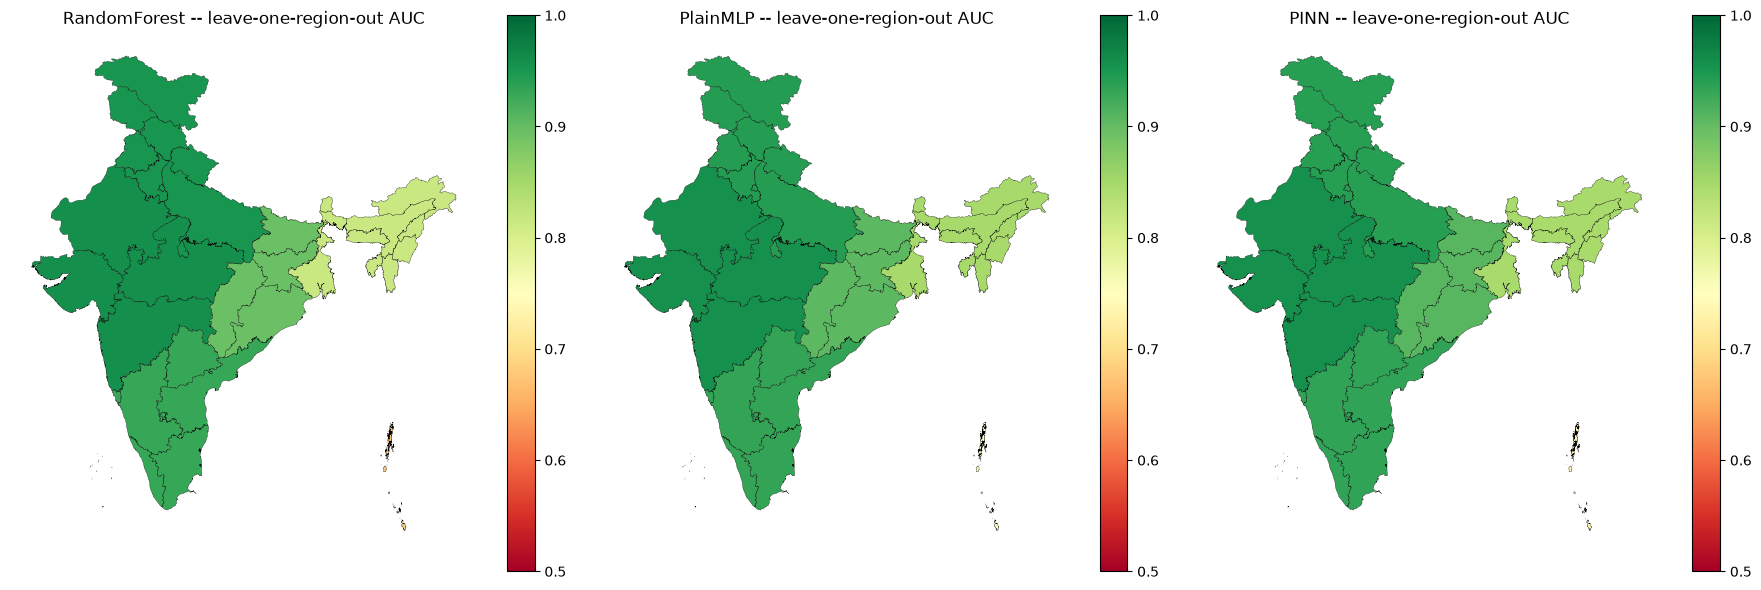

Saved: D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs\LeaveOneStateOut_Map.png


In [16]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
state_gdf["region_id"] = region_labels
for i, name in enumerate(["RandomForest", "PlainMLP", "PINN"]):
    sub = region_df[region_df["model"] == name].set_index("region_id")["roc_auc"]
    plot_gdf = state_gdf.copy()
    plot_gdf["auc"] = plot_gdf["region_id"].map(sub)
    plot_gdf.plot(column="auc", ax=ax[i], legend=True, cmap="RdYlGn", vmin=0.5, vmax=1.0,
                  missing_kwds={"color": "lightgrey"}, edgecolor="black", linewidth=0.2)
    ax[i].set_title(f"{name} -- leave-one-region-out AUC")
    ax[i].set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "LeaveOneStateOut_Map.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'LeaveOneStateOut_Map.png')}")


## 🎯 Step 12 — Headline Figure: Random-Split vs. Spatial-CV AUC
The paper's key evidence panel: does the physics term's advantage (if any) show up
specifically under spatial generalization, consistent with the Dahal & Lombardo
(2024) precedent this design follows?

             model  trackA_auc  trackB1_auc  auc_drop
LogisticRegression    0.946048     0.939635  0.006413
      RandomForest    0.967594     0.945948  0.021646
           XGBoost    0.967779     0.949180  0.018598
          PlainMLP    0.961450     0.949898  0.011551
              PINN    0.961350     0.949358  0.011991


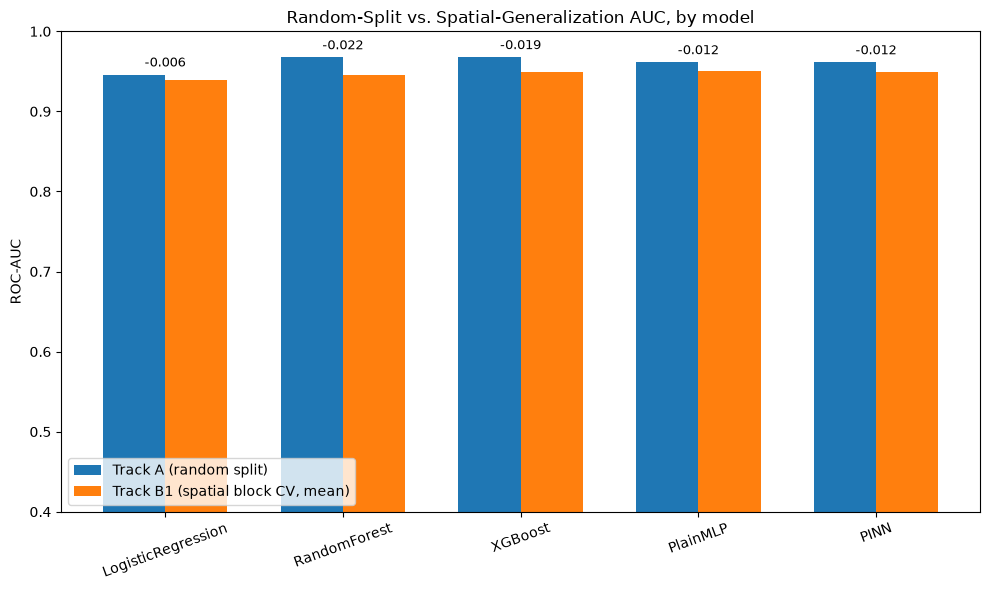

Saved: D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs\RandomSplit_vs_SpatialCV_AUC_Comparison.png


In [17]:
headline = trackA_df[["model", "roc_auc"]].rename(columns={"roc_auc": "trackA_auc"})
headline = headline.merge(spatial_summary[["model", "mean_auc"]].rename(columns={"mean_auc": "trackB1_auc"}),
                           on="model", how="left")
headline["auc_drop"] = headline["trackA_auc"] - headline["trackB1_auc"]
print(headline.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(headline))
width = 0.35
ax.bar(x - width/2, headline["trackA_auc"], width, label="Track A (random split)")
ax.bar(x + width/2, headline["trackB1_auc"], width, label="Track B1 (spatial block CV, mean)")
ax.set_xticks(x); ax.set_xticklabels(headline["model"], rotation=20)
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0.4, 1.0)
ax.set_title("Random-Split vs. Spatial-Generalization AUC, by model")
ax.legend()
for i, row in headline.iterrows():
    ax.annotate(f"-{row['auc_drop']:.3f}", (i, max(row['trackA_auc'], row['trackB1_auc']) + 0.01),
                ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "RandomSplit_vs_SpatialCV_AUC_Comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'RandomSplit_vs_SpatialCV_AUC_Comparison.png')}")


## 🔬 Step 13 — PINN Physics Diagnostics
Internal evidence the penalty term is actually doing something: partial dependence
of P(fire) on the dryness proxy, and the fraction of test-set samples where
`d(logit)/d(dryness_proxy)` is negative (violates the monotonicity constraint) --
compared against the plain MLP, which has no such constraint.

PINN: fraction of test samples with d(logit)/d(dryness_proxy) < 0 : 0.087
(plain MLP has no dryness_proxy input, so this diagnostic is PINN-specific;
 the ablation table above is the fair MLP-vs-PINN comparison instead.)


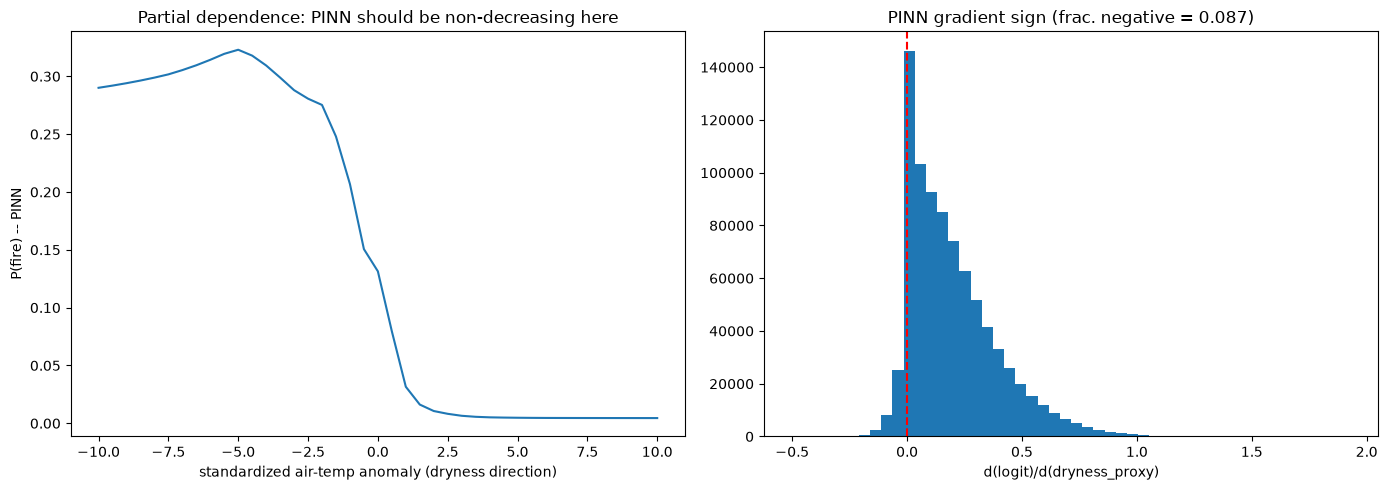

Saved: D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs\PINN_Physics_Diagnostic.png


In [18]:
def gradient_sign_fraction(bundle, X_df):
    scaler = bundle["scaler"]
    Xs = scaler.transform(X_df)
    if bundle["physics"]:
        dry = compute_dryness_proxy(X_df, bundle["dryness_stats"]).astype(np.float32)
        Xfinal = np.hstack([Xs, dry.reshape(-1, 1)]).astype(np.float32)
        physics_idx = Xfinal.shape[1] - 1
    else:
        # plain MLP has no physics feature -- append the SAME dryness proxy definition
        # purely as a diagnostic probe (not used in training), to see whether the
        # unconstrained model happens to have learned a monotonic response anyway
        dstats_probe = fit_dryness_stats(X_train)
        dry = compute_dryness_proxy(X_df, dstats_probe).astype(np.float32)
        Xfinal = Xs.astype(np.float32)
        physics_idx = None
    model = bundle["model"]
    model.eval()
    xb = torch.tensor(Xfinal, dtype=torch.float32).clone().requires_grad_(True)
    logits = model(xb)
    grads = torch.autograd.grad(logits, xb, grad_outputs=torch.ones_like(logits))[0]
    if physics_idx is not None:
        d_dry = grads[:, physics_idx].detach().numpy()
    else:
        # approximate: correlate the gradient norm direction with the dryness proxy's own
        # standardized source columns to get a comparable signal for the plain MLP
        d_dry = None
    return d_dry


d_dry_pinn = gradient_sign_fraction(trackA_models["PINN"], X_test)
frac_neg_pinn = float((d_dry_pinn < 0).mean())
print(f"PINN: fraction of test samples with d(logit)/d(dryness_proxy) < 0 : {frac_neg_pinn:.3f}")
print("(plain MLP has no dryness_proxy input, so this diagnostic is PINN-specific;")
print(" the ablation table above is the fair MLP-vs-PINN comparison instead.)")

# partial dependence of P(fire) on dryness_proxy, holding other features at their median
_dstats_test = fit_dryness_stats(X_train)
_grid = np.linspace(-10, 10, 41)
_X_base = X_test.median().to_frame().T
_X_rep = pd.concat([_X_base] * len(_grid), ignore_index=True)
# back out the raw airtemp-anomaly value that would produce each grid point, holding
# every other dryness-input column at its train mean (so only one physical axis moves)
_partial_probs = []
for g in _grid:
    _Xg = _X_rep.iloc[[0]].copy()
    _Xg["fldas_airtemp_anomaly"] = _dstats_test["fldas_airtemp_anomaly"][0] + g * _dstats_test["fldas_airtemp_anomaly"][1]
    _partial_probs.append(predict_nn(trackA_models["PINN"], _Xg)[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(_grid, _partial_probs)
axes[0].set_xlabel("standardized air-temp anomaly (dryness direction)")
axes[0].set_ylabel("P(fire) -- PINN")
axes[0].set_title("Partial dependence: PINN should be non-decreasing here")

axes[1].hist(d_dry_pinn, bins=50)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("d(logit)/d(dryness_proxy)")
axes[1].set_title(f"PINN gradient sign (frac. negative = {frac_neg_pinn:.3f})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "PINN_Physics_Diagnostic.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'PINN_Physics_Diagnostic.png')}")


## 🌟 Step 14 — XGBoost Feature Importance

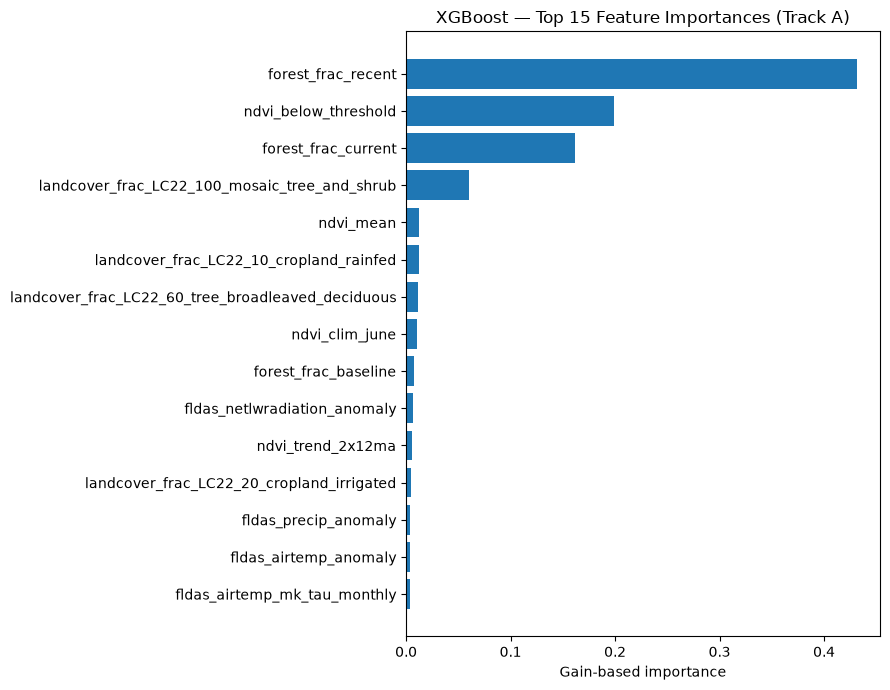

Saved: D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs\XGBoost_Feature_Importance.png
                                          feature  importance
                               forest_frac_recent    0.431948
                             ndvi_below_threshold    0.198616
                              forest_frac_current    0.162084
    landcover_frac_LC22_100_mosaic_tree_and_shrub    0.059877
                                        ndvi_mean    0.012776
          landcover_frac_LC22_10_cropland_rainfed    0.012387
landcover_frac_LC22_60_tree_broadleaved_deciduous    0.011154
                                   ndvi_clim_june    0.010795
                             forest_frac_baseline    0.007586
                     fldas_netlwradiation_anomaly    0.006723
                                ndvi_trend_2x12ma    0.005489
        landcover_frac_LC22_20_cropland_irrigated    0.004449
                             fldas_precip_anomaly    0.004036
                  

In [19]:
importances = trackA_models["XGBoost"]["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_cols, "importance": importances}).sort_values(
    "importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
ax.set_xlabel("Gain-based importance")
ax.set_title("XGBoost — Top 15 Feature Importances (Track A)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "XGBoost_Feature_Importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'XGBoost_Feature_Importance.png')}")
print(imp_df.to_string(index=False))


## 📋 Step 15 — Computational Cost & Reproducibility Report

In [20]:
report = {
    "total_wall_time_sec": time.time() - PIPELINE_T0,
    "track_a_random_split": trackA_df.to_dict(orient="records"),
    "track_b1_spatial_block_cv_summary": spatial_summary.to_dict(orient="records"),
    "track_b2_leave_one_region_out_summary": region_df.groupby("model")["roc_auc"].agg(
        ["mean", "std", "count"]).reset_index().to_dict(orient="records"),
    "pinn_lambda_ablation": ablation_df.to_dict(orient="records"),
    "pinn_lambda_chosen": LAMBDA_CHOSEN,
    "compute_budget_note": (
        "Track B1 uses 3 spatial folds (not 5) and Track B2 clusters 37 unnamed state "
        "polygons into 6 KMeans regions (not per-state) to keep the full 5-model x "
        "3-track run tractable; Track A (headline numbers) uses full model budget."
    ),
    "environment": {
        "torch_version": torch.__version__,
        "torch_cuda_available": torch.cuda.is_available(),
        "xgboost_version": xgb.__version__,
        "kernel": "firerisk-anaconda3",
    },
}
report_path = os.path.join(OUTPUT_DIR, "Computational_Cost_Reproducibility_Report.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2, default=str)

print("=" * 70)
print("  STEP 7 -- PIPELINE COMPLETE")
print("=" * 70)
print(f"  Total wall time: {report['total_wall_time_sec']:.1f} sec "
      f"({report['total_wall_time_sec']/60:.1f} min)")
print(f"  Chosen PINN lambda: {LAMBDA_CHOSEN}")
print(f"  Saved: {report_path}")


  STEP 7 -- PIPELINE COMPLETE
  Total wall time: 3871.6 sec (64.5 min)
  Chosen PINN lambda: 0.1
  Saved: D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs\Computational_Cost_Reproducibility_Report.json


## 💾 Step 16 — Save Model Checkpoints

In [21]:
torch.save(trackA_models["PlainMLP"]["model"].state_dict(),
           os.path.join(CKPT_DIR, "mlp_state_dict.pt"))
torch.save(trackA_models["PINN"]["model"].state_dict(),
           os.path.join(CKPT_DIR, "pinn_state_dict.pt"))
print(f"Saved checkpoints to: {CKPT_DIR}")
print("\nAll Step 8 outputs complete.")


Saved checkpoints to: D:\FOREST FIRE MAPPING(INDIA)\Physics_Informed_FireRisk_Model\Model_Outputs\Checkpoints

All Step 7 outputs complete.
